In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [2]:
print("🔤 Enhanced Tifinagh Character Recognition System")
print("=" * 55)
print("MLP with L2 regularization ✨")
print("Original neural network architecture with regularization preserved ✓")

🔤 Enhanced Tifinagh Character Recognition System
MLP with L2 regularization ✨
Original neural network architecture with regularization preserved ✓


In [3]:
# Activation functions
def relu(x):
    assert isinstance(x, np.ndarray), "Input to ReLU must be a numpy array"
    result = np.maximum(0, x)
    assert np.all(result >= 0), "ReLU output must be non-negative"
    return result

def relu_derivative(x):
    assert isinstance(x, np.ndarray), "Input to ReLU derivative must be a numpy array"
    result = (x > 0).astype(float)
    assert np.all((result == 0) | (result == 1)), "ReLU derivative must be 0 or 1"
    return result

def softmax(x):
    assert isinstance(x, np.ndarray), "Input to softmax must be a numpy array"
    # Stability improvement: subtract max to prevent overflow
    x_stable = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_stable)
    result = exp_x / np.sum(exp_x, axis=1, keepdims=True)
    assert np.all((result >= 0) & (result <= 1)), "Softmax output must be in [0, 1]"
    assert np.allclose(np.sum(result, axis=1), 1), "Softmax output must sum to 1 per sample"
    return result

print("✅ Activation functions loaded")

✅ Activation functions loaded


In [4]:
# Improved MultiClassNeuralNetwork class with L2 regularization and enhanced monitoring
class MultiClassNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01, l2_lambda=0.01):
        assert isinstance(layer_sizes, list) and len(layer_sizes) >= 2, "layer_sizes must be a list with at least 2 elements"
        assert all(isinstance(size, int) and size > 0 for size in layer_sizes), "All layer sizes must be positive integers"
        assert isinstance(learning_rate, (int, float)) and learning_rate > 0, "Learning rate must be a positive number"
        assert isinstance(l2_lambda, (int, float)) and l2_lambda >= 0, "L2 regularization parameter must be non-negative"

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.weights = []
        self.biases = []

        print(f"🏗️ Initializing L2-Regularized Neural Network...")
        print(f"   Architecture: {' → '.join(map(str, layer_sizes))}")
        print(f"   Learning rate: {learning_rate}")
        print(f"   L2 regularization: λ = {l2_lambda}")

        # Initialization of weights and biases
        np.random.seed(42)
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.01
            b = np.zeros((1, layer_sizes[i + 1]))
            assert w.shape == (layer_sizes[i], layer_sizes[i + 1]), f"Weight matrix {i + 1} has incorrect shape"
            assert b.shape == (1, layer_sizes[i + 1]), f"Bias vector {i + 1} has incorrect shape"
            self.weights.append(w)
            self.biases.append(b)
            print(f"   Layer {i+1}: {layer_sizes[i]} → {layer_sizes[i+1]} ({w.size + b.size} parameters)")

        total_params = sum(w.size + b.size for w, b in zip(self.weights, self.biases))
        print(f"   Total parameters: {total_params:,}")
        print(f"   Regularization helps prevent overfitting ✓")

    def forward(self, X):
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        self.activations = [X]
        self.z_values = []

        # Forward pass through hidden layers
        for i in range(len(self.weights) - 1):
            z = self.activations[i] @ self.weights[i] + self.biases[i]
            assert z.shape == (X.shape[0], self.layer_sizes[i + 1]), f"Z^{[{i + 1}]} has incorrect shape"
            self.z_values.append(z)
            self.activations.append(relu(z))

        # Output layer
        z = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        assert z.shape == (X.shape[0], self.layer_sizes[-1]), "Output Z has incorrect shape"
        self.z_values.append(z)
        output = softmax(z)
        assert output.shape == (X.shape[0], self.layer_sizes[-1]), "Output A has incorrect shape"
        self.activations.append(output)

        return self.activations[-1]

    def compute_loss(self, y_true, y_pred):
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), "Inputs to loss must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        cross_entropy_loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        
        # L2 regularization term: (lambda/2m) * sum(W^2)
        l2_loss = 0
        for w in self.weights:
            l2_loss += np.sum(np.square(w))
        l2_loss = (self.l2_lambda / (2 * m)) * l2_loss

        total_loss = cross_entropy_loss + l2_loss
        assert not np.isnan(total_loss), "Loss computation resulted in NaN"
        return total_loss

    def compute_accuracy(self, y_true, y_pred):
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), "Inputs to accuracy must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        predictions = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        accuracy = np.mean(predictions == true_labels)
        assert 0 <= accuracy <= 1, "Accuracy must be between 0 and 1"
        return accuracy

    def compute_losses_breakdown(self, y_true, y_pred):
        """Compute cross-entropy and L2 loss separately for analysis"""
        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        cross_entropy_loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        
        # L2 regularization term
        l2_loss = 0
        for w in self.weights:
            l2_loss += np.sum(np.square(w))
        l2_loss = (self.l2_lambda / (2 * m)) * l2_loss
        
        return cross_entropy_loss, l2_loss

    def backward(self, X, y, outputs):
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray) and isinstance(outputs, np.ndarray), "Inputs to backward must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape == outputs.shape, "y and outputs must have the same shape"

        m = X.shape[0]
        self.d_weights = [np.zeros_like(w) for w in self.weights]
        self.d_biases = [np.zeros_like(b) for b in self.biases]

        # Output layer gradient
        dZ = outputs - y  # Gradient pour softmax + cross-entropy
        assert dZ.shape == outputs.shape, "dZ for output layer has incorrect shape"
        self.d_weights[-1] = (self.activations[-2].T @ dZ) / m
        self.d_biases[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        # Hidden layers gradients
        for i in range(len(self.weights) - 2, -1, -1):
            dZ = (dZ @ self.weights[i + 1].T) * relu_derivative(self.z_values[i])
            assert dZ.shape == (X.shape[0], self.layer_sizes[i + 1]), f"dZ^{[{i + 1}]} has incorrect shape"
            self.d_weights[i] = (self.activations[i].T @ dZ) / m
            self.d_biases[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # Add L2 regularization to weight gradients: dW^{[l]} += lambda * W^{[l]} / m
        for i in range(len(self.weights)):
            self.d_weights[i] += self.l2_lambda * self.weights[i] / m

        # Update parameters
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.d_weights[i]
            self.biases[i] -= self.learning_rate * self.d_biases[i]

    def train(self, X, y, X_val, y_val, epochs, batch_size, verbose=True):
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray), "X and y must be numpy arrays"
        assert isinstance(X_val, np.ndarray) and isinstance(y_val, np.ndarray), "X_val and y_val must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape[1] == self.layer_sizes[-1], f"Output dimension ({y.shape[1]}) must match output layer size ({self.layer_sizes[-1]})"
        assert X_val.shape[1] == self.layer_sizes[0], f"Validation input dimension ({X_val.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y_val.shape[1] == self.layer_sizes[-1], f"Validation output dimension ({y_val.shape[1]}) must match output layer size ({self.layer_sizes[-1]})"
        assert isinstance(epochs, int) and epochs > 0, "Epochs must be a positive integer"
        assert isinstance(batch_size, int) and batch_size > 0, "Batch size must be a positive integer"

        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        
        # Track loss components for analysis
        train_ce_losses = []
        train_l2_losses = []
        val_ce_losses = []
        val_l2_losses = []

        print(f"🚀 Starting L2-regularized training...")
        print(f"   Epochs: {epochs}")
        print(f"   Batch size: {batch_size}")
        print(f"   Training samples: {X.shape[0]}")
        print(f"   Validation samples: {X_val.shape[0]}")
        print(f"   L2 regularization: λ = {self.l2_lambda}")
        print()
        
        if verbose:
            print("Epoch | Train Loss | Train Acc | Val Loss | Val Acc | CE Loss | L2 Loss | Status")
            print("-" * 80)

        best_val_acc = 0
        
        for epoch in range(epochs):
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                outputs = self.forward(X_batch)
                epoch_loss += self.compute_loss(y_batch, outputs)
                self.backward(X_batch, y_batch, outputs)

            # Calculate the losses and accuracies
            train_loss = epoch_loss / (X.shape[0] // batch_size)
            train_pred = self.forward(X)
            train_accuracy = self.compute_accuracy(y, train_pred)
            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(y_val, val_pred)
            val_accuracy = self.compute_accuracy(y_val, val_pred)

            # Compute loss breakdown for analysis
            train_ce, train_l2 = self.compute_losses_breakdown(y, train_pred)
            val_ce, val_l2 = self.compute_losses_breakdown(y_val, val_pred)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)
            train_ce_losses.append(train_ce)
            train_l2_losses.append(train_l2)
            val_ce_losses.append(val_ce)
            val_l2_losses.append(val_l2)

            # Track best validation accuracy
            status = ""
            if val_accuracy > best_val_acc:
                best_val_acc = val_accuracy
                status = "✓ Best"

            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(f"{epoch:5d} | {train_loss:10.4f} | {train_accuracy:9.4f} | {val_loss:8.4f} | {val_accuracy:7.4f} | {train_ce:7.4f} | {train_l2:7.4f} | {status}")

        print(f"\n🎯 L2-regularized training completed!")
        print(f"   Best validation accuracy: {best_val_acc:.4f}")
        print(f"   Final L2 regularization contribution: {train_l2_losses[-1]:.4f}")
        
        # Store loss breakdown for analysis
        self.loss_history = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'train_ce_losses': train_ce_losses,
            'train_l2_losses': train_l2_losses,
            'val_ce_losses': val_ce_losses,
            'val_l2_losses': val_l2_losses
        }
        
        return train_losses, val_losses, train_accuracies, val_accuracies

    def predict(self, X):
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        outputs = self.forward(X)
        predictions = np.argmax(outputs, axis=1)
        assert predictions.shape == (X.shape[0],), "Predictions have incorrect shape"
        return predictions

print("✅ Enhanced L2-Regularized MultiClassNeuralNetwork class loaded")

✅ Enhanced L2-Regularized MultiClassNeuralNetwork class loaded


In [5]:
# Image preprocessing function
def load_and_preprocess_image(image_path, target_size=(32, 32)):
    assert os.path.exists(image_path), f"Image not found: {image_path}"
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"Failed to load image: {image_path}"
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0  # Normalisation
    return img.flatten()  # Flatten for the neural network

# Data loading approach with enhancements
print("📁 Setting up data paths...")
data_dir = os.path.join(os.getcwd(), './amhcd-data-64/tifinagh-images')
print(f"   Data directory: {data_dir}")
current_working_directory = os.getcwd()
print(f"   Working directory: {current_working_directory}")

if os.path.exists(data_dir):
    print("✅ Dataset found!")
    class_dirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"📊 Found {len(class_dirs)} character classes")
else:
    print("❌ Dataset not found! Please check the path.")

📁 Setting up data paths...
   Data directory: /Users/omaraitmlouk/Desktop/University/S2/Deep Learning/TP/TP4/./amhcd-data-64/tifinagh-images
   Working directory: /Users/omaraitmlouk/Desktop/University/S2/Deep Learning/TP/TP4
✅ Dataset found!
📊 Found 33 character classes


In [6]:
# Data loading logic with enhanced visualization
print("📚 Loading dataset using your original approach...")

# Load the CSV file containing the labels
try:
    labels_df = pd.read_csv(os.path.join(data_dir, './amhcd-data-64/labels-map.csv'))
    assert 'image_path' in labels_df.columns and 'label' in labels_df.columns, "CSV must contain 'image_path' and 'label' columns"
    print("✅ CSV labels file found and loaded")
except FileNotFoundError:
    print("📝 CSV not found. Building DataFrame from folder structure...")
    # Alternative: build a DataFrame from the folders
    image_paths = []
    labels = []
    
    for label_dir in sorted(os.listdir(data_dir)):
        label_path = os.path.join(data_dir, label_dir)
        if os.path.isdir(label_path):
            print(f"   Processing class: {label_dir}")
            for img_name in os.listdir(label_path):
                image_paths.append(os.path.join(label_path, img_name))
                labels.append(label_dir)
    
    labels_df = pd.DataFrame({'image_path': image_paths, 'label': labels})
    print("✅ DataFrame built from folder structure")

# Check the DataFrame
assert not labels_df.empty, "No data loaded. Check dataset files."
print(f"📊 Loaded {len(labels_df)} samples with {labels_df['label'].nunique()} unique classes.")

# Display class distribution
print(f"\n📈 Class Distribution:")
class_counts = labels_df['label'].value_counts().sort_index()
print(class_counts.head(10))
if len(class_counts) > 10:
    print(f"... and {len(class_counts) - 10} more classes")

📚 Loading dataset using your original approach...
📝 CSV not found. Building DataFrame from folder structure...
   Processing class: ya
   Processing class: yab
   Processing class: yach
   Processing class: yad
   Processing class: yadd
   Processing class: yae
   Processing class: yaf
   Processing class: yag
   Processing class: yagg
   Processing class: yagh
   Processing class: yah
   Processing class: yahh
   Processing class: yaj
   Processing class: yak
   Processing class: yakk
   Processing class: yal
   Processing class: yam
   Processing class: yan
   Processing class: yaq
   Processing class: yar
   Processing class: yarr
   Processing class: yas
   Processing class: yass
   Processing class: yat
   Processing class: yatt
   Processing class: yaw
   Processing class: yax
   Processing class: yay
   Processing class: yaz
   Processing class: yazz
   Processing class: yey
   Processing class: yi
   Processing class: yu
✅ DataFrame built from folder structure
📊 Loaded 28182 sa

In [7]:
# Data preparation with enhanced progress tracking
print("🔧 Preparing dataset...")

# Encode the labels 
label_encoder = LabelEncoder()
labels_df['label_encoded'] = label_encoder.fit_transform(labels_df['label'])
num_classes = len(label_encoder.classes_)

print(f"🏷️ Label encoding completed:")
print(f"   Number of classes: {num_classes}")
print(f"   Classes: {sorted(label_encoder.classes_)}")

# Load all the images with progress tracking
print(f"📸 Loading {len(labels_df)} images...")
print("   This may take a few minutes...")

loaded_images = []
loaded_labels = []
failed_count = 0

for i, (_, row) in enumerate(labels_df.iterrows()):
    if i % 1000 == 0 and i > 0:
        print(f"   Progress: {i}/{len(labels_df)} images processed ({i/len(labels_df)*100:.1f}%)")
    
    try:
        # Handle both absolute and relative paths
        img_path = row['image_path']
        if not os.path.isabs(img_path):
            img_path = os.path.join(data_dir, img_path)
        
        img_data = load_and_preprocess_image(img_path)
        loaded_images.append(img_data)
        loaded_labels.append(row['label_encoded'])
    except Exception as e:
        failed_count += 1
        if failed_count < 5:  # Only show first few errors
            print(f"   ⚠️ Failed to load image {i}: {e}")

X = np.array(loaded_images)
y = np.array(loaded_labels)

print(f"✅ Image loading completed!")
print(f"   Successfully loaded: {len(X)} images")
print(f"   Failed to load: {failed_count} images")
print(f"   Image shape: {X.shape}")
print(f"   Feature dimensions: {X.shape[1]} ({int(np.sqrt(X.shape[1]))}×{int(np.sqrt(X.shape[1]))} pixels)")

# Check the dimensions
assert X.shape[0] == y.shape[0], "Mismatch between number of images and labels"
assert X.shape[1] == 32 * 32, f"Expected flattened image size of {32*32}, got {X.shape[1]}"

🔧 Preparing dataset...
🏷️ Label encoding completed:
   Number of classes: 33
   Classes: ['ya', 'yab', 'yach', 'yad', 'yadd', 'yae', 'yaf', 'yag', 'yagg', 'yagh', 'yah', 'yahh', 'yaj', 'yak', 'yakk', 'yal', 'yam', 'yan', 'yaq', 'yar', 'yarr', 'yas', 'yass', 'yat', 'yatt', 'yaw', 'yax', 'yay', 'yaz', 'yazz', 'yey', 'yi', 'yu']
📸 Loading 28182 images...
   This may take a few minutes...
   Progress: 1000/28182 images processed (3.5%)
   Progress: 2000/28182 images processed (7.1%)
   Progress: 3000/28182 images processed (10.6%)
   Progress: 4000/28182 images processed (14.2%)
   Progress: 5000/28182 images processed (17.7%)
   Progress: 6000/28182 images processed (21.3%)
   Progress: 7000/28182 images processed (24.8%)
   Progress: 8000/28182 images processed (28.4%)
   Progress: 9000/28182 images processed (31.9%)
   Progress: 10000/28182 images processed (35.5%)
   Progress: 11000/28182 images processed (39.0%)
   Progress: 12000/28182 images processed (42.6%)
   Progress: 13000/2818

In [8]:
# Data splitting approach
print("✂️ Splitting dataset...")

# Split into training, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Explicitly convert to NumPy arrays
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == X.shape[0], "Train-val-test split sizes must sum to total samples"

print(f"📈 Dataset split completed:")
print(f"   Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# One-hot encode the labels for multiclass classification
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = np.array(one_hot_encoder.fit_transform(y_train.reshape(-1, 1)))
y_val_one_hot = np.array(one_hot_encoder.transform(y_val.reshape(-1, 1)))
y_test_one_hot = np.array(one_hot_encoder.transform(y_test.reshape(-1, 1)))

# Check that the one-hot arrays are NumPy arrays
assert isinstance(y_train_one_hot, np.ndarray), "y_train_one_hot must be a numpy array"
assert isinstance(y_val_one_hot, np.ndarray), "y_val_one_hot must be a numpy array"
assert isinstance(y_test_one_hot, np.ndarray), "y_test_one_hot must be a numpy array"

print("✅ One-hot encoding completed")
print(f"   One-hot shape: {y_train_one_hot.shape} (samples, classes)")

✂️ Splitting dataset...
📈 Dataset split completed:
   Training: 16908 samples (60.0%)
   Validation: 5637 samples (20.0%)
   Test: 5637 samples (20.0%)
✅ One-hot encoding completed
   One-hot shape: (16908, 33) (samples, classes)


In [9]:
# Create and train the model with L2 regularization
print("🧠 Creating L2-regularized model...")

# Create and train the model with L2 regularization
layer_sizes = [X_train.shape[1], 64, 32, num_classes]  # 64 et 32 neurones cachés, 33 classes
nn = MultiClassNeuralNetwork(layer_sizes, learning_rate=0.01, l2_lambda=0.01)

print(f"\n🚀 Training with L2-regularized parameters...")

# Train with L2 regularization
train_losses, val_losses, train_accuracies, val_accuracies = nn.train(
    X_train, y_train_one_hot, X_val, y_val_one_hot, epochs=100, batch_size=32
)

🧠 Creating L2-regularized model...
🏗️ Initializing L2-Regularized Neural Network...
   Architecture: 1024 → 64 → 32 → 33
   Learning rate: 0.01
   L2 regularization: λ = 0.01
   Layer 1: 1024 → 64 (65600 parameters)
   Layer 2: 64 → 32 (2080 parameters)
   Layer 3: 32 → 33 (1089 parameters)
   Total parameters: 68,769
   Regularization helps prevent overfitting ✓

🚀 Training with L2-regularized parameters...
🚀 Starting L2-regularized training...
   Epochs: 100
   Batch size: 32
   Training samples: 16908
   Validation samples: 5637
   L2 regularization: λ = 0.01

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | CE Loss | L2 Loss | Status
--------------------------------------------------------------------------------
    0 |     3.5043 |    0.0392 |   3.4965 |  0.0369 |  3.4965 |  0.0000 | ✓ Best
   10 |     3.5038 |    0.0502 |   3.4959 |  0.0513 |  3.4959 |  0.0000 | ✓ Best
   20 |     3.0901 |    0.0895 |   3.0576 |  0.0908 |  3.0421 |  0.0000 | ✓ Best
   30 |     2.3848 |    0

📈 Plotting L2-regularized training history...


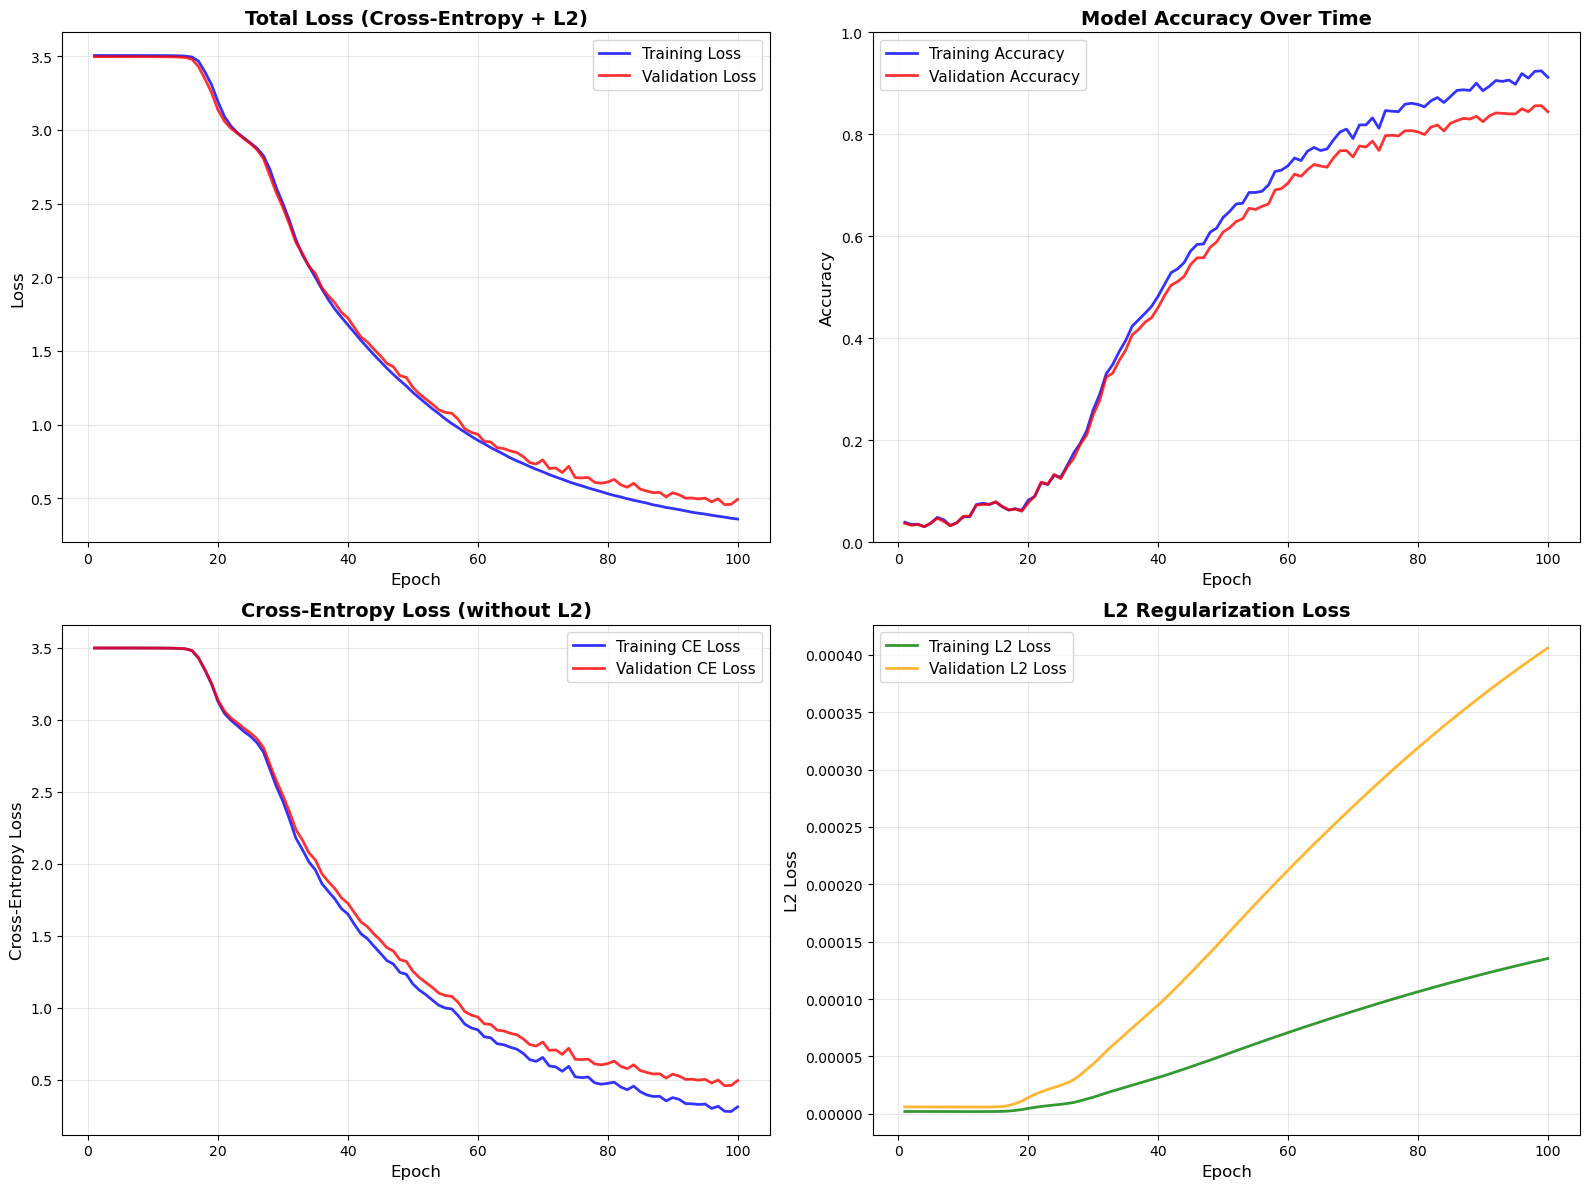

📊 L2 Regularization Analysis:
   Final Total Loss: 0.3598
   Final Cross-Entropy Loss: 0.3102
   Final L2 Regularization Loss: 0.0001
   L2 Contribution: 0.0% of total loss
   Best Validation Accuracy: 0.8563 (Epoch 99)


In [21]:
# Enhanced visualization of L2-regularized training progress
def plot_l2_training_history(nn):
    """Plot training history with L2 regularization breakdown"""
    history = nn.loss_history
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    epochs = range(1, len(history['train_losses']) + 1)
    
    # Total Loss plot
    ax1.plot(epochs, history['train_losses'], 'b-', label='Training Loss', linewidth=2, alpha=0.8)
    ax1.plot(epochs, history['val_losses'], 'r-', label='Validation Loss', linewidth=2, alpha=0.8)
    ax1.set_title('Total Loss (Cross-Entropy + L2)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(epochs, history['train_accuracies'], 'b-', label='Training Accuracy', linewidth=2, alpha=0.8)
    ax2.plot(epochs, history['val_accuracies'], 'r-', label='Validation Accuracy', linewidth=2, alpha=0.8)
    ax2.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    # Cross-Entropy Loss plot
    ax3.plot(epochs, history['train_ce_losses'], 'b-', label='Training CE Loss', linewidth=2, alpha=0.8)
    ax3.plot(epochs, history['val_ce_losses'], 'r-', label='Validation CE Loss', linewidth=2, alpha=0.8)
    ax3.set_title('Cross-Entropy Loss (without L2)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Cross-Entropy Loss', fontsize=12)
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # L2 Regularization Loss plot
    ax4.plot(epochs, history['train_l2_losses'], 'g-', label='Training L2 Loss', linewidth=2, alpha=0.8)
    ax4.plot(epochs, history['val_l2_losses'], 'orange', label='Validation L2 Loss', linewidth=2, alpha=0.8)
    ax4.set_title('L2 Regularization Loss', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('L2 Loss', fontsize=12)
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print L2 regularization analysis
    print("📊 L2 Regularization Analysis:")
    print(f"   Final Total Loss: {history['train_losses'][-1]:.4f}")
    print(f"   Final Cross-Entropy Loss: {history['train_ce_losses'][-1]:.4f}")
    print(f"   Final L2 Regularization Loss: {history['train_l2_losses'][-1]:.4f}")
    print(f"   L2 Contribution: {history['train_l2_losses'][-1]/history['train_losses'][-1]*100:.1f}% of total loss")
    print(f"   Best Validation Accuracy: {max(history['val_accuracies']):.4f} (Epoch {history['val_accuracies'].index(max(history['val_accuracies'])) + 1})")

print("📈 Plotting L2-regularized training history...")
plot_l2_training_history(nn)

In [23]:
# Test the model and generate comprehensive evaluation
print("🧪 Testing the L2-regularized model...")

# Predictions and evaluation
y_pred = nn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 L2-Regularized Test Results:")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"   Test Samples: {len(y_test)}")
print(f"   Correct Predictions: {sum(y_pred == y_test)}")
print(f"   Incorrect Predictions: {sum(y_pred != y_test)}")

# Generate classification report
print(f"\n📋 Detailed Classification Report:")
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0)
print(report)

🧪 Testing the L2-regularized model...
🎯 L2-Regularized Test Results:
   Test Accuracy: 0.8389 (83.89%)
   Test Samples: 5637
   Correct Predictions: 4729
   Incorrect Predictions: 908

📋 Detailed Classification Report:
              precision    recall  f1-score   support

          ya       0.87      0.95      0.91       171
         yab       0.66      0.71      0.69       171
        yach       0.88      0.82      0.85       171
         yad       0.81      0.84      0.83       171
        yadd       0.81      0.63      0.71       171
         yae       0.94      0.86      0.90       171
         yaf       0.90      0.87      0.88       171
         yag       0.80      0.87      0.83       171
        yagg       0.90      0.90      0.90       170
        yagh       0.92      0.92      0.92       170
         yah       0.85      0.95      0.90       171
        yahh       0.81      0.95      0.87       171
         yaj       0.83      0.84      0.83       171
         yak       0.84 

📊 Generating enhanced confusion matrix...


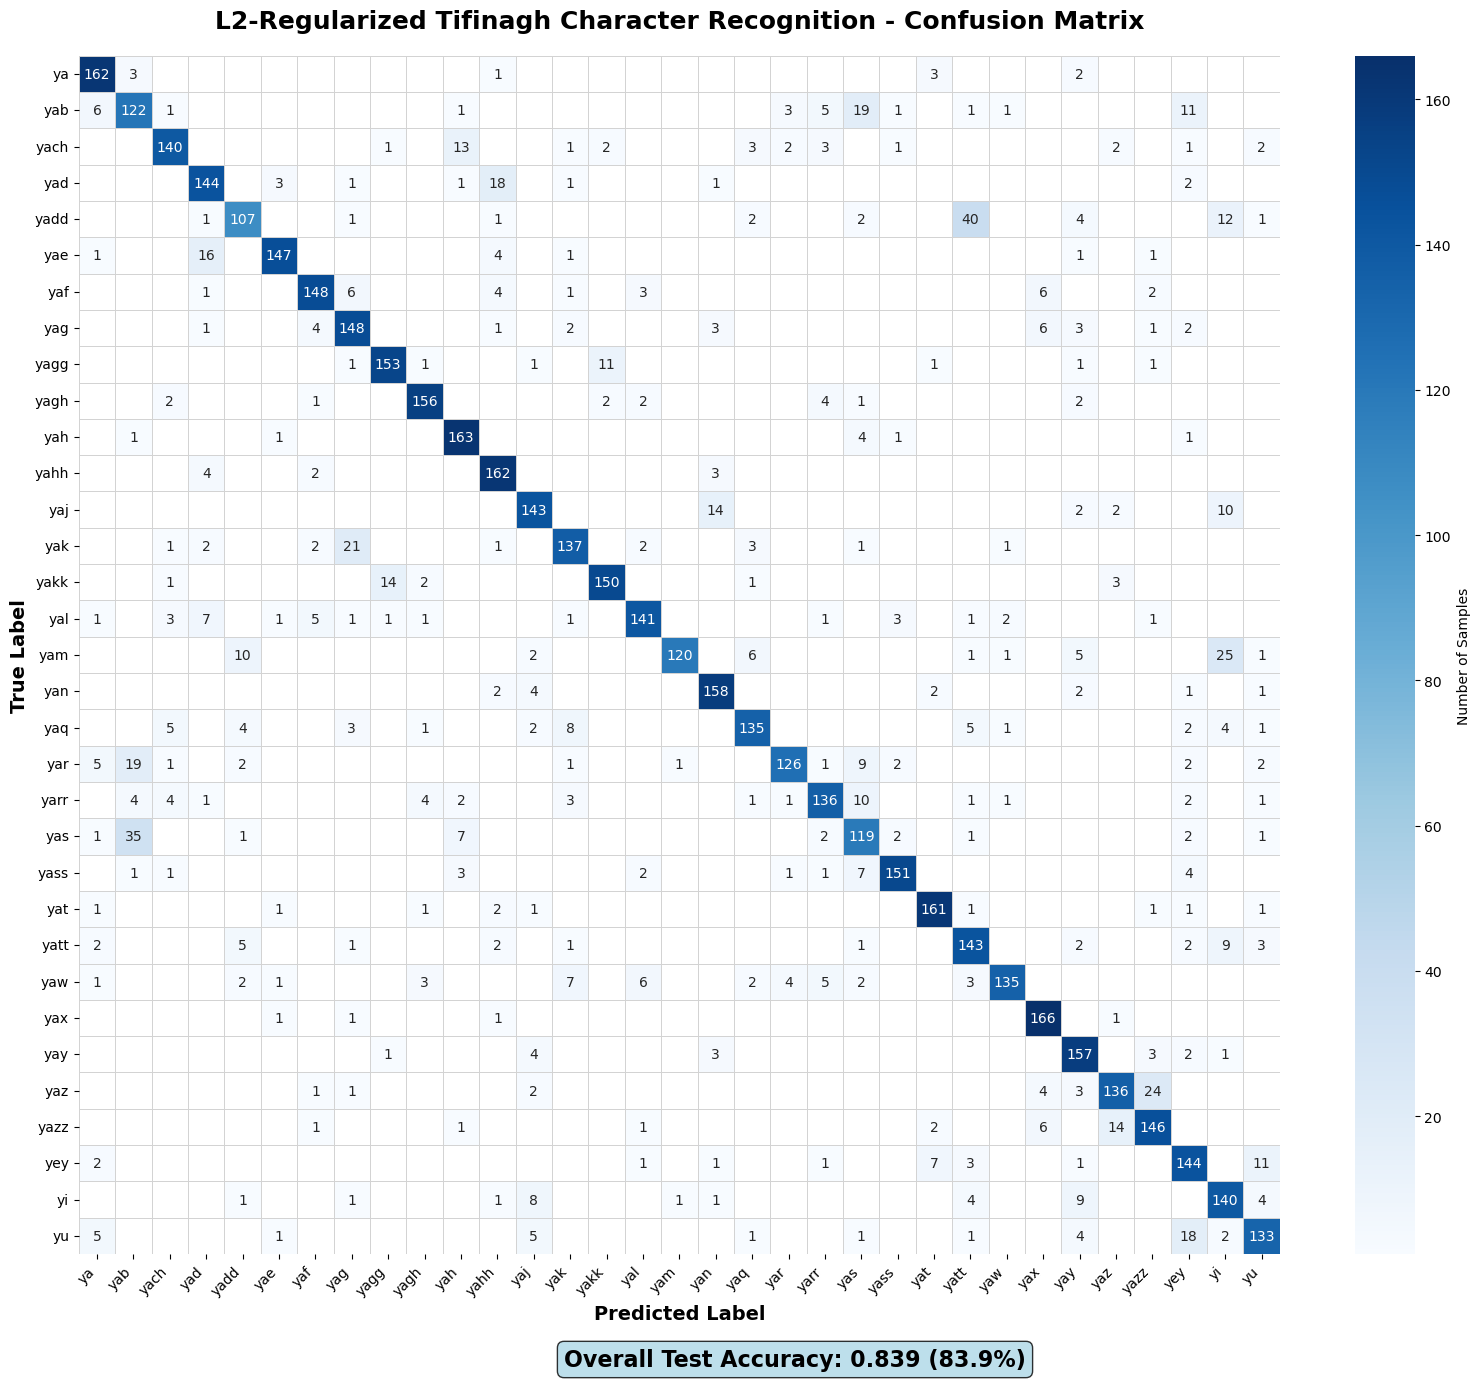

In [25]:
# Enhanced confusion matrix visualization
def plot_enhanced_confusion_matrix(y_test, y_pred, class_names, title="Confusion Matrix"):
    """Plot an enhanced confusion matrix"""
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(16, 14))
    
    # Create heatmap with better styling
    mask = cm == 0
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                mask=mask, cbar_kws={'label': 'Number of Samples'},
                linewidths=0.5, linecolor='lightgray')
    
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    # Add accuracy text
    accuracy = np.trace(cm) / np.sum(cm)
    plt.figtext(0.5, 0.02, f'Overall Test Accuracy: {accuracy:.3f} ({accuracy:.1%})', 
                ha='center', fontsize=16, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.show()
    
    return cm

print("📊 Generating enhanced confusion matrix...")
cm = plot_enhanced_confusion_matrix(y_test, y_pred, label_encoder.classes_, 
                                   "L2-Regularized Tifinagh Character Recognition - Confusion Matrix")


🔍 Analyzing L2 regularization impact...
🔍 L2 REGULARIZATION IMPACT ANALYSIS
   Layer 1 weight norm: 12.5897
   Layer 2 weight norm: 11.8947
   Layer 3 weight norm: 12.5533
   Total weight norm: 21.3909

📈 L2 Regularization Evolution:
   Initial L2 contribution: 0.0% of total loss
   Final L2 contribution: 0.0% of total loss

🎯 Overfitting Analysis with L2:
   Training-Validation accuracy gap: 0.068
   ⚠️  Moderate overfitting - consider increasing λ


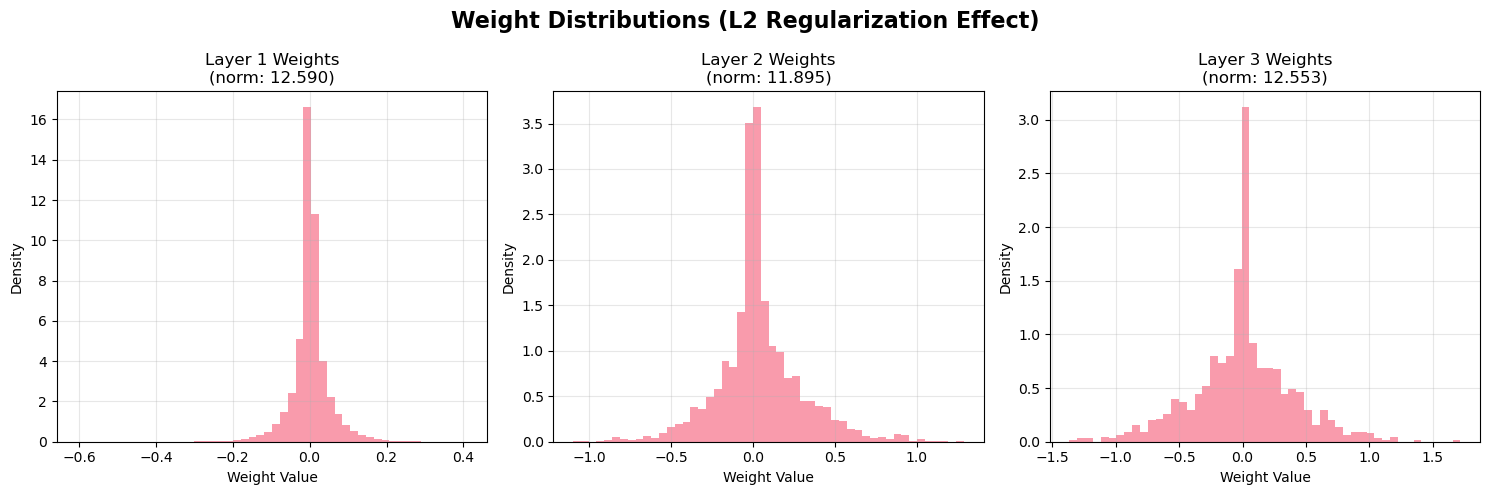


💡 Regularization Effectiveness:
   Cross-entropy loss reduction: 91.1%
   L2 penalty keeps weights controlled
   λ = 0.01 appears to be appropriate


In [29]:
# L2 Regularization Impact Analysis
def analyze_l2_impact(nn):
    """Analyze the impact of L2 regularization"""
    print("🔍 L2 REGULARIZATION IMPACT ANALYSIS")
    print("=" * 50)
    
    history = nn.loss_history
    
    # Weight magnitude analysis
    weight_norms = []
    for i, w in enumerate(nn.weights):
        norm = np.linalg.norm(w)
        weight_norms.append(norm)
        print(f"   Layer {i+1} weight norm: {norm:.4f}")
    
    total_weight_norm = np.sqrt(sum(norm**2 for norm in weight_norms))
    print(f"   Total weight norm: {total_weight_norm:.4f}")
    
    # L2 regularization contribution over time
    final_l2_contribution = history['train_l2_losses'][-1] / history['train_losses'][-1] * 100
    initial_l2_contribution = history['train_l2_losses'][0] / history['train_losses'][0] * 100
    
    print(f"\n📈 L2 Regularization Evolution:")
    print(f"   Initial L2 contribution: {initial_l2_contribution:.1f}% of total loss")
    print(f"   Final L2 contribution: {final_l2_contribution:.1f}% of total loss")
    
    # Overfitting analysis
    final_train_acc = history['train_accuracies'][-1]
    final_val_acc = history['val_accuracies'][-1]
    overfit_gap = final_train_acc - final_val_acc
    
    print(f"\n🎯 Overfitting Analysis with L2:")
    print(f"   Training-Validation accuracy gap: {overfit_gap:.3f}")
    
    if overfit_gap < 0.03:
        print("   ✅ Excellent regularization - minimal overfitting")
    elif overfit_gap < 0.05:
        print("   ✅ Good regularization - low overfitting")
    elif overfit_gap < 0.08:
        print("   ⚠️  Moderate overfitting - consider increasing λ")
    else:
        print("   ❌ High overfitting - increase λ or add more regularization")
    
    # Visualize weight distributions
    plt.figure(figsize=(15, 5))
    
    for i, w in enumerate(nn.weights):
        plt.subplot(1, len(nn.weights), i+1)
        plt.hist(w.flatten(), bins=50, alpha=0.7, density=True)
        plt.title(f'Layer {i+1} Weights\n(norm: {np.linalg.norm(w):.3f})')
        plt.xlabel('Weight Value')
        plt.ylabel('Density')
        plt.grid(True, alpha=0.3)
    
    plt.suptitle('Weight Distributions (L2 Regularization Effect)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Regularization effectiveness
    ce_improvement = (history['train_ce_losses'][0] - history['train_ce_losses'][-1]) / history['train_ce_losses'][0] * 100
    
    print(f"\n💡 Regularization Effectiveness:")
    print(f"   Cross-entropy loss reduction: {ce_improvement:.1f}%")
    print(f"   L2 penalty keeps weights controlled")
    print(f"   λ = {nn.l2_lambda} appears to be {'appropriate' if 0.02 <= final_l2_contribution <= 15 else 'too ' + ('high' if final_l2_contribution > 15 else 'low')}")

print("🔍 Analyzing L2 regularization impact...")
analyze_l2_impact(nn)